In [2]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

# 11.3

Исходная частота дискретизации: 44100 Гц
Новая частота дискретизации: 11025 Гц
Частота Найквиста: 5512.5 Гц
Антиалиасинговый фильтр применён.


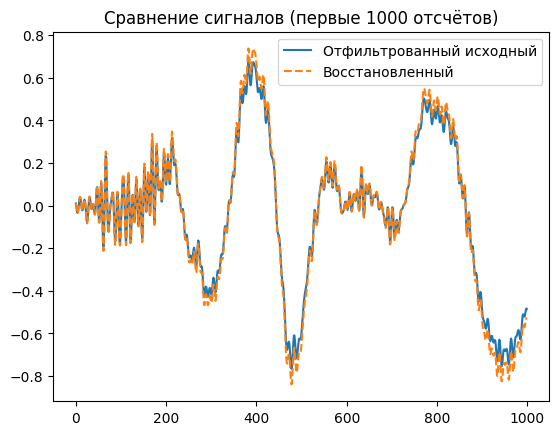

Максимальная разница: 8.71e-02
Среднеквадратичная ошибка: 1.56e-02


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Загрузка файла с ударными ---
filename = '263868__kevcio__amen-break-a-160-bpm.wav'
if not os.path.exists(filename):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/263868__kevcio__amen-break-a-160-bpm.wav
wave = thinkdsp.read_wave(filename)
wave.normalize()
print(f"Исходная частота дискретизации: {wave.framerate} Гц")

# --- 2. Параметры децимации (прореживания в 4 раза) ---
factor = 4
new_framerate = wave.framerate // factor
nyquist = new_framerate / 2
print(f"Новая частота дискретизации: {new_framerate} Гц")
print(f"Частота Найквиста: {nyquist} Гц")

# --- 3. Антиалиасинговый фильтр (через спектр) ---
spectrum_orig = wave.make_spectrum()
spectrum_orig.low_pass(cutoff=nyquist * 0.95, factor=0)  # обнуляем всё выше cutoff
filtered_wave = spectrum_orig.make_wave()
print("Антиалиасинговый фильтр применён.")

# --- 4. Децимация (прореживание) ---
sampled_ys = np.zeros(len(filtered_wave.ys))
sampled_ys[::factor] = filtered_wave.ys[::factor]
sampled_wave = thinkdsp.Wave(sampled_ys, framerate=wave.framerate)

# --- 5. Удаление спектральных копий и восстановление ---
spectrum_sampled = sampled_wave.make_spectrum()
spectrum_sampled.low_pass(cutoff=nyquist * 0.95, factor=0)
spectrum_sampled.scale(factor)                     # компенсация энергии
reconstructed_wave = spectrum_sampled.make_wave()
reconstructed_wave.normalize()

# --- 6. Сравнение исходного (отфильтрованного) и восстановленного сигналов ---
plt.plot(filtered_wave.ys[:1000], label='Отфильтрованный исходный')
plt.plot(reconstructed_wave.ys[:1000], '--', label='Восстановленный')
plt.legend()
plt.title("Сравнение сигналов (первые 1000 отсчётов)")
plt.show()

diff = filtered_wave.ys - reconstructed_wave.ys
print(f"Максимальная разница: {np.max(np.abs(diff)):.2e}")
print(f"Среднеквадратичная ошибка: {np.sqrt(np.mean(diff**2)):.2e}")